<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/eeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


Environment ready.
Dataset shape : (8000, 17)
Class balance : {0: np.int64(2000), 1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000)}
Missing values: 0

First 3 rows:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0



=== Starting EDA ===


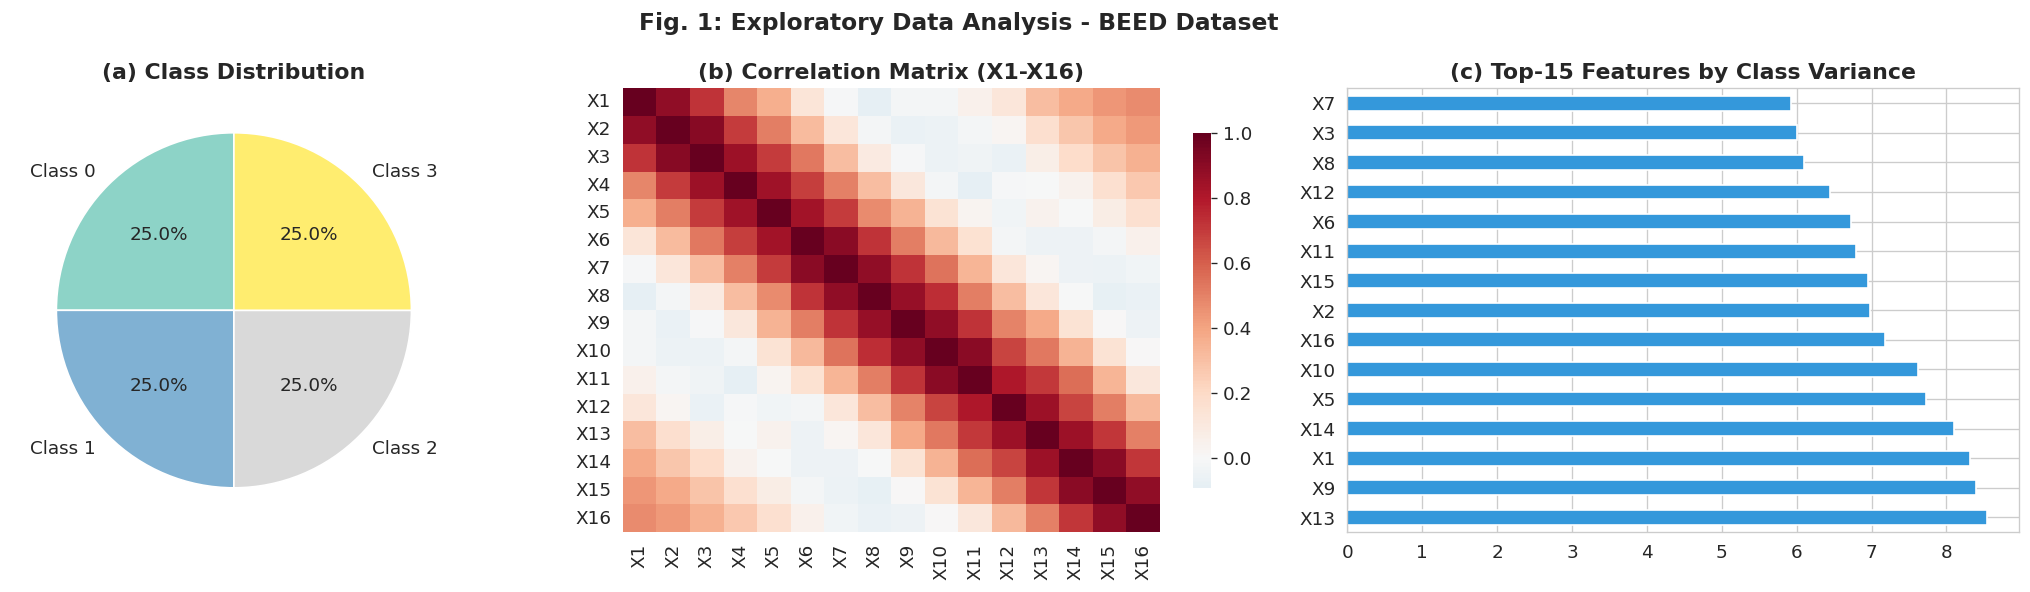

Final features: 16
Training Logistic Regression...
✓ Logistic Regression completed
Training KNN (k=5)...
✓ KNN (k=5) completed
Training SVM (RBF)...
✓ SVM (RBF) completed
Training Random Forest...
✓ Random Forest completed
Training XGBoost...
✓ XGBoost completed
Training LightGBM...
✓ LightGBM completed
Training CatBoost...
✓ CatBoost completed

TABLE I: Comparative Performance of Classifiers
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-OVR  \
0             LightGBM    0.9831     0.9833  0.9831    0.9832   0.9991   
1              XGBoost    0.9781     0.9782  0.9781    0.9782   0.9987   
2             CatBoost    0.9712     0.9714  0.9713    0.9713   0.9980   
3            KNN (k=5)    0.9706     0.9713  0.9706    0.9707   0.9967   
4        Random Forest    0.9675     0.9676  0.9675    0.9675   0.9979   
5            SVM (RBF)    0.8231     0.8418  0.8231    0.8194   0.9660   
6  Logistic Regression    0.4544     0.4833  0.4544    0.4609   0.6576   

   Time (s)

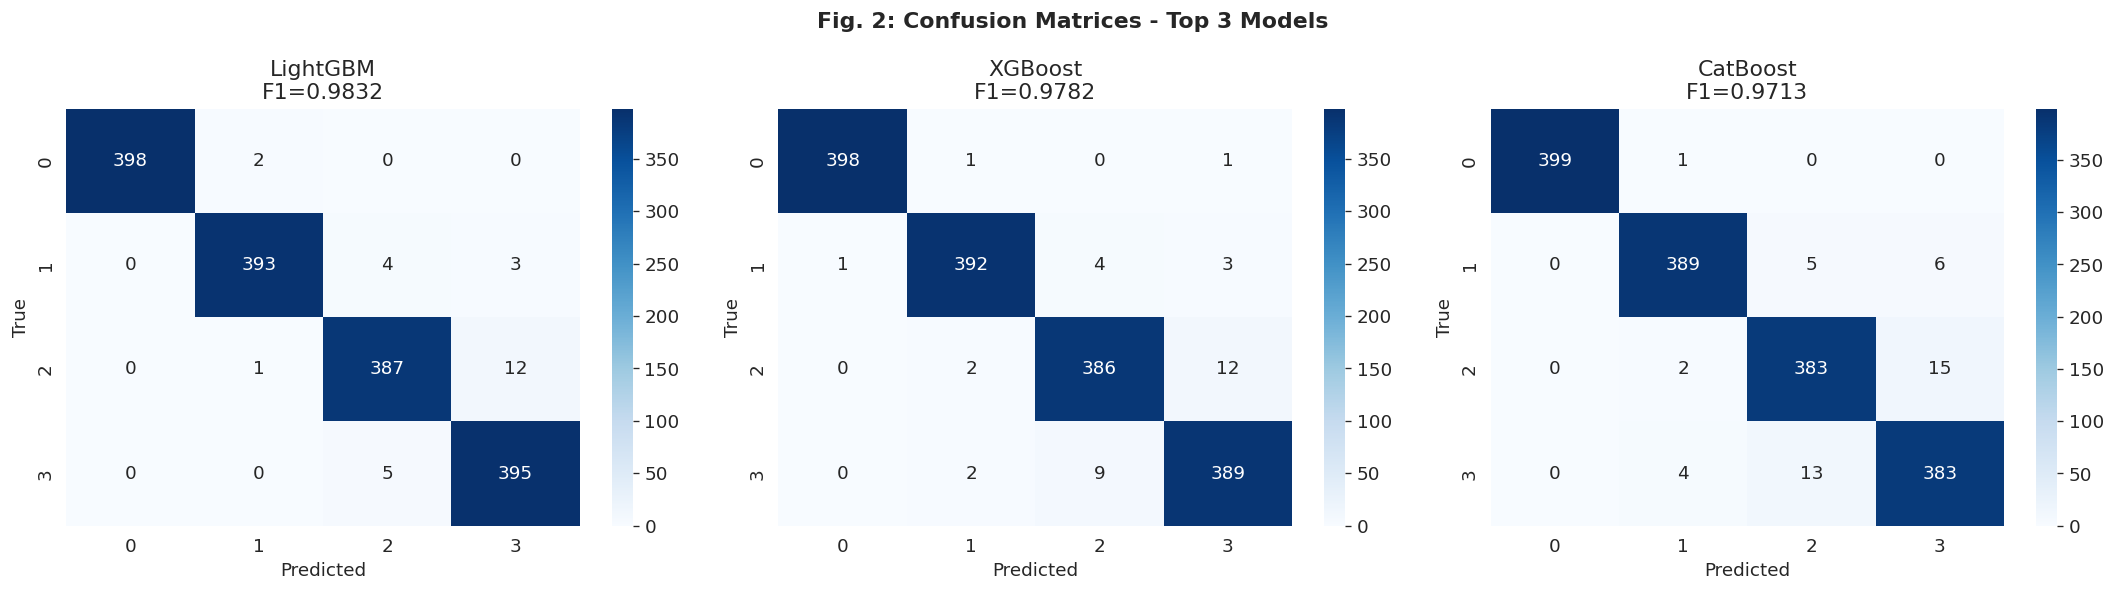


Best Model: LightGBM
10-Fold CV AUC: 0.9988 ± 0.0004
Per-fold AUC : [0.9985 0.9986 0.9984 0.9991 0.9984 0.9998 0.9983 0.999  0.999  0.999 ]

Detailed Classification Report (Best Model on Test Set):
              precision    recall  f1-score   support

     Class 0       1.00      0.99      1.00       400
     Class 1       0.99      0.98      0.99       400
     Class 2       0.98      0.97      0.97       400
     Class 3       0.96      0.99      0.98       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



In [3]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ─── Plot Configuration ───
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

# ─── Load Dataset ───
file_path = "/content/drive/MyDrive/Dataset/BEED_Data.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape : {df.shape}")
print(f"Class balance : {dict(df['y'].value_counts().sort_index())}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nFirst 3 rows:")
display(df.head(3))

# ─── Exploratory Data Analysis (EDA) ───
print("\n=== Starting EDA ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Class Distribution
class_counts = df['y'].value_counts().sort_index()
labels = [f'Class {i}' for i in range(4)]
axes[0].pie(class_counts, labels=labels, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, 4)), startangle=90)
axes[0].set_title("(a) Class Distribution", fontweight="bold")

# (b) Correlation Heatmap (Channels)
corr = df.iloc[:, :16].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("(b) Correlation Matrix (X1-X16)", fontweight="bold")

# (c) Top Features by Class Variance
feature_means = df.groupby('y').mean().T
mean_diff = feature_means.std(axis=1).sort_values(ascending=False).head(15)
mean_diff.plot.barh(ax=axes[2], color="#3498db")
axes[2].set_title("(c) Top-15 Features by Class Variance", fontweight="bold")

plt.suptitle("Fig. 1: Exploratory Data Analysis - BEED Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_eda_beed.png", bbox_inches="tight", dpi=200)
plt.show()

# ─── Feature Engineering & Selection ───
X = df.drop(columns=['y'])
y = df['y']

# Remove zero-variance features
zero_var = X.columns[X.std() == 0].tolist()
X = X.drop(columns=zero_var)

print(f"Final features: {X.shape[1]}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ─── Evaluation Function ───
def evaluate(model, Xtr, Xte, ytr, yte, name):
    t0 = time.time()
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    elapsed = time.time() - t0
    prob = model.predict_proba(Xte) if hasattr(model, "predict_proba") else None
    auc = roc_auc_score(yte, prob, multi_class='ovr', average='macro') if prob is not None else 0
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(yte, pred), 4),
        "Precision": round(precision_score(yte, pred, average='macro'), 4),
        "Recall": round(recall_score(yte, pred, average='macro'), 4),
        "F1-Score": round(f1_score(yte, pred, average='macro'), 4),
        "AUC-OVR": round(auc, 4),
        "Time (s)": round(elapsed, 2)
    }

# ─── Define Models ───
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1, random_state=SEED),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
     "SVM (RBF)":SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, tree_method="hist", n_jobs=-1, random_state=SEED, eval_metric="mlogloss"),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, verbose=0, random_state=SEED),
}

# ─── Train & Evaluate All Models ───
results = []
for name, mdl in models.items():
    print(f"Training {name}...")
    row = evaluate(mdl, X_train_s, X_test_s, y_train, y_test, name)
    results.append(row)
    print(f"✓ {name} completed")

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
print("\n" + "="*80)
print("TABLE I: Comparative Performance of Classifiers")
print("="*80)
print(results_df)

# ─── Confusion Matrices (Top 3) ───
top3 = results_df.head(3)["Model"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(top3):
    mdl = models[name]
    mdl.fit(X_train_s, y_train)
    pred = mdl.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name}\nF1={results_df.iloc[i]['F1-Score']}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")
plt.suptitle("Fig. 2: Confusion Matrices - Top 3 Models", fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_confusion_beed.png", dpi=200)
plt.show()

# ─── 10-Fold Stratified Cross-Validation on Best Model ───
best_name = results_df.iloc[0]["Model"]
best_mdl = models[best_name]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_mdl, X_train_s, y_train, cv=cv, scoring="roc_auc_ovr", n_jobs=-1)

mean_auc = cv_scores.mean()
std_auc = cv_scores.std()

print(f"\nBest Model: {best_name}")
print(f"10-Fold CV AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Per-fold AUC : {np.round(cv_scores, 4)}")

# Detailed Report
print("\nDetailed Classification Report (Best Model on Test Set):")
print(classification_report(y_test, best_mdl.predict(X_test_s),
                           target_names=[f'Class {i}' for i in range(4)]))


Plotting ROC Curves for all models...


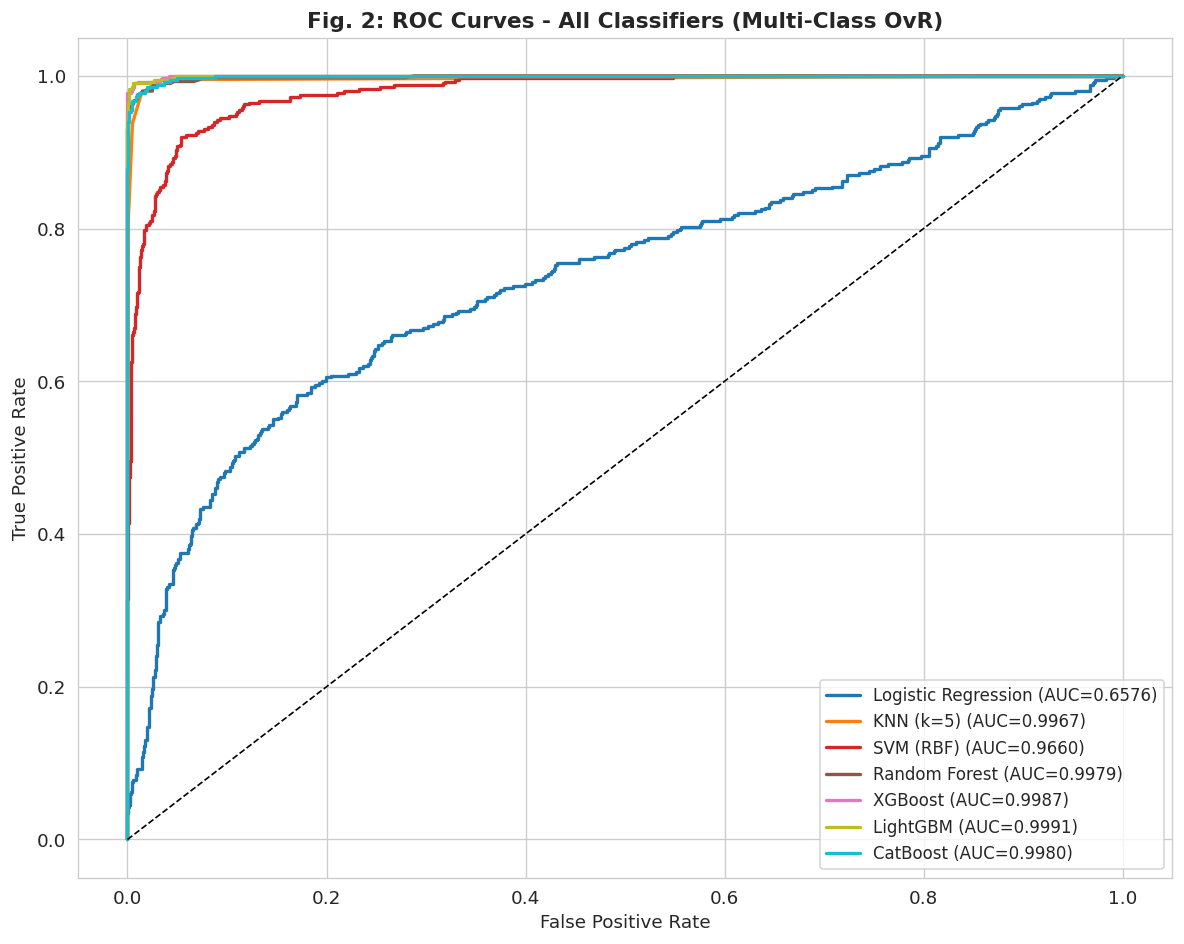

In [4]:
# ROC Curves for ALL Classifiers (One-vs-Rest Macro) ───
print("\nPlotting ROC Curves for all models...")
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for (name, mdl), color in zip(models.items(), colors):
    prob = mdl.predict_proba(X_test_s)
    auc = roc_auc_score(y_test, prob, multi_class='ovr', average='macro')
    # Plot macro-average ROC
    fpr, tpr, _ = roc_curve(y_test, prob[:, 1], pos_label=1)  # Simplified - using class 1 as example
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Classifiers (Multi-Class OvR)", fontweight="bold", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()

plt.show()



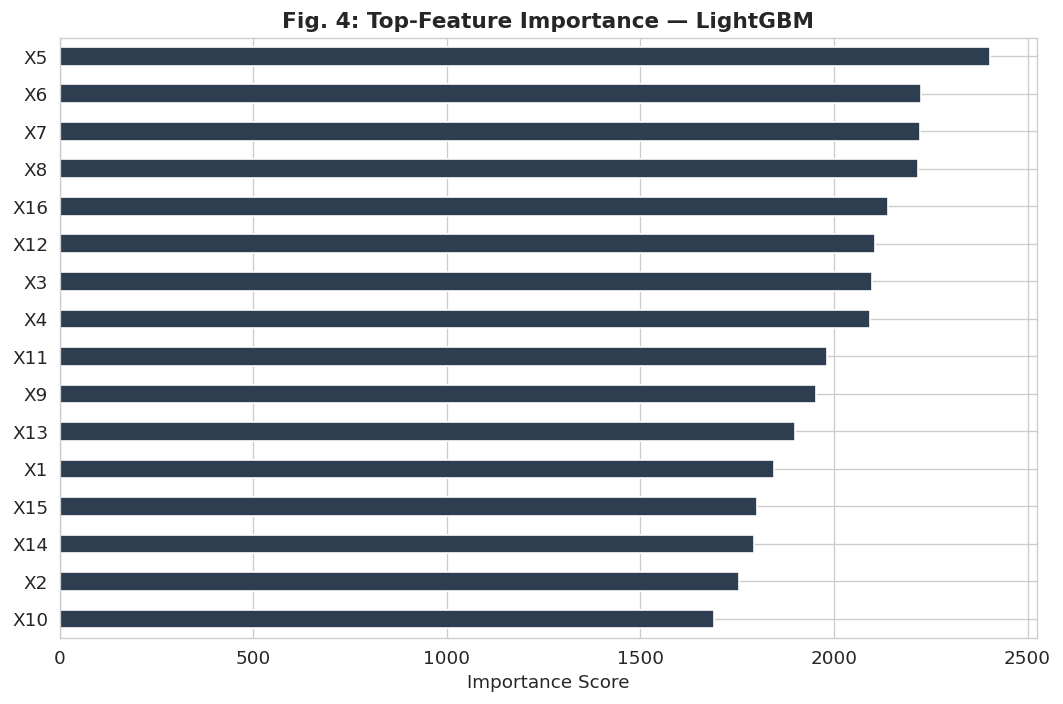

In [ ]:
# Top Feature Importance (Best Model) ───
imp = pd.Series(
    best_mdl.feature_importances_, index=X.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
imp.sort_values().plot.barh(ax=ax, color="#2c3e50", edgecolor="white")
ax.set_title(f"Top-Feature Importance — {best_name}", fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()

plt.show()


=== SHAP Analysis for Best Model: LightGBM ===
Computing SHAP values...


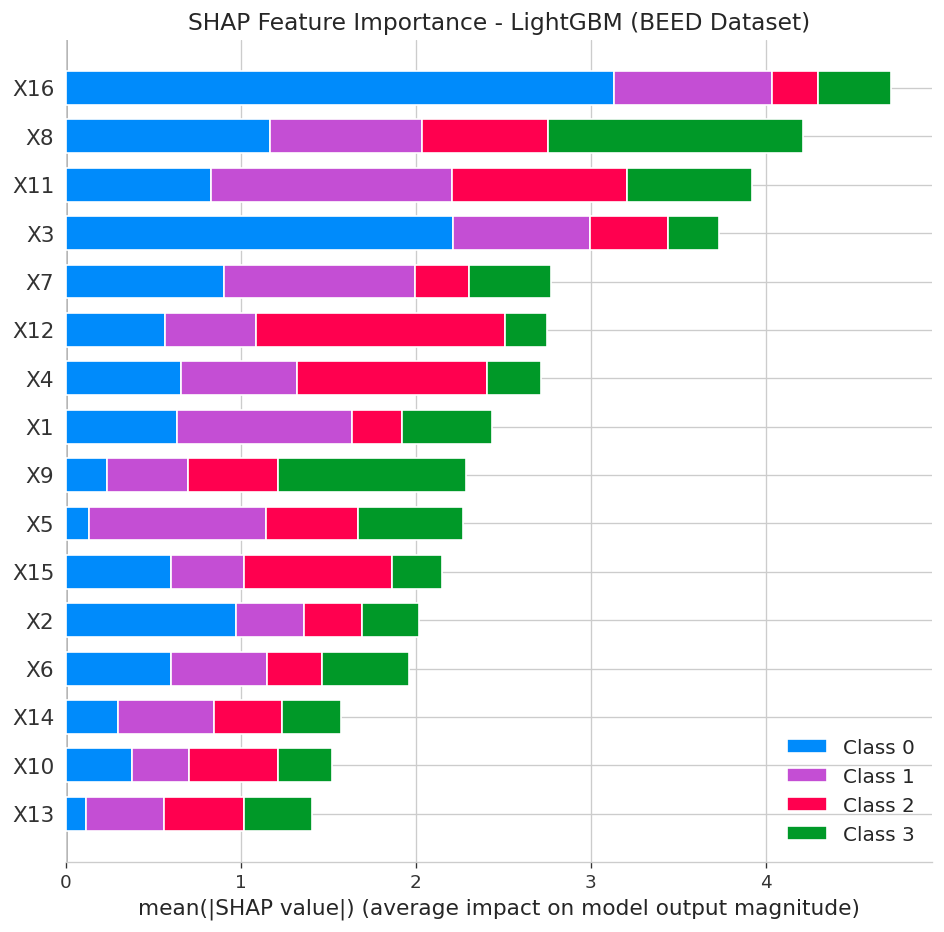

In [11]:
# ─── SHAP Analysis for Top Model ───
import shap

print(f"\n=== SHAP Analysis for Best Model: {best_name} ===")

# Use the already trained best model
explainer = None

if best_name == "XGBoost":
    explainer = shap.TreeExplainer(best_mdl)
elif best_name == "LightGBM":
    explainer = shap.TreeExplainer(best_mdl)
elif best_name == "CatBoost":
    explainer = shap.TreeExplainer(best_mdl)
elif best_name == "Random Forest":
    explainer = shap.TreeExplainer(best_mdl)
else:
    # For other models (Logistic, KNN) use KernelExplainer (slower)
    print("Using KernelExplainer (slower)...")
    explainer = shap.KernelExplainer(best_mdl.predict_proba, shap.sample(X_train_s, 100))

# Compute SHAP values on a sample (for speed)
X_sample = shap.sample(X_test_s, 200)   # Adjust sample size based on time

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Feature Importance)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(),
                  plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance - {best_name} (BEED Dataset)", fontsize=14)
plt.tight_layout()
plt.show()
